> # SECTION -3
<h4>

**Create quantum circuits**

--- 
- **Construct basic quantum circuits**
- Construct dynamic circuits
- Construct parameterized circuits
- Transpile and optimize circuits
---

</h4>

In [1]:
from platform import python_version
import qiskit
print("Python version ", python_version())
print(f"Qiskit version: {qiskit.__version__}")

Python version  3.13.5
Qiskit version: 2.5.0


> ## Construct basic quantum circuits

REFERENCE : 

https://quantum.cloud.ibm.com/docs/en/guides/construct-circuits

https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.QuantumCircuit

https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#circuit-attributes

**Quantum Circuit:**
- collection of qubits 
- a list of instructions that act on those qubits

---

Quantum circuit with 2 qubits 

---

In [2]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)
qc.qubits

[<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>]

---

Quantum circuit with 2 qubits and 2 bits

---

In [3]:
qc = QuantumCircuit(2,2)
print(qc.qubits)
print(qc.clbits)

[<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>]
[<Clbit register=(2, "c"), index=0>, <Clbit register=(2, "c"), index=1>]


---

Quantum circuit using quantum register and classical register

---

In [4]:
from qiskit.circuit import QuantumRegister, ClassicalRegister

qr1 = QuantumRegister(2, "qreg1")  # Create a QuantumRegister with 2 qubits

cr1 = ClassicalRegister(3, "creg1")  # Create a ClassicalRegister with 3 cbits

qc = QuantumCircuit(qr1,cr1)

print(qc.qubits)
print(qc.clbits)

[<Qubit register=(2, "qreg1"), index=0>, <Qubit register=(2, "qreg1"), index=1>]
[<Clbit register=(3, "creg1"), index=0>, <Clbit register=(3, "creg1"), index=1>, <Clbit register=(3, "creg1"), index=2>]


In [5]:
print(qr1)
print(cr1)

QuantumRegister(2, 'qreg1')
ClassicalRegister(3, 'creg1')


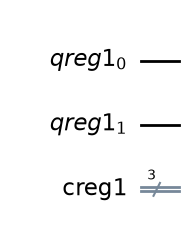

In [6]:
qc.draw(output="mpl")

---

Quantum circuit with multiple quantum register

---

In [7]:
from qiskit.circuit import QuantumRegister, ClassicalRegister

qr1 = QuantumRegister(2, "qreg1")  # Create a QuantumRegister with 2 qubits

qr2 = QuantumRegister(3, "qreg2")  # Create a QuantumRegister with 2 qubits

cr1 = ClassicalRegister(3, "creg1")  # Create a ClassicalRegister with 3 cbits

qc = QuantumCircuit(qr1,qr2,cr1)



In [8]:
qc.qubits

[<Qubit register=(2, "qreg1"), index=0>,
 <Qubit register=(2, "qreg1"), index=1>,
 <Qubit register=(3, "qreg2"), index=0>,
 <Qubit register=(3, "qreg2"), index=1>,
 <Qubit register=(3, "qreg2"), index=2>]

In [9]:
qc.clbits

[<Clbit register=(3, "creg1"), index=0>,
 <Clbit register=(3, "creg1"), index=1>,
 <Clbit register=(3, "creg1"), index=2>]

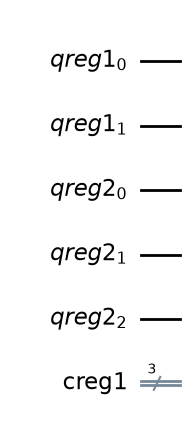

In [10]:
qc.draw(output="mpl")

---

Add an instruction to the circuit

---

In [11]:
#appends the instruction to the circuit's data attribute.
qc.x(0)
qc.data

[CircuitInstruction(operation=Instruction(name='x', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "qreg1"), index=0>,), clbits=())]

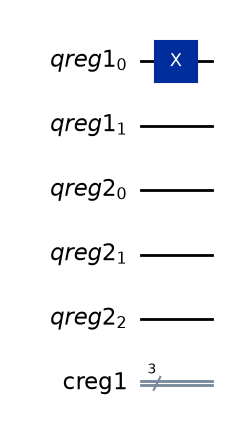

In [12]:
qc.draw(output="mpl")

---
For example, the X-gate is defined as a specific case of the U3-gate

---

In [13]:
qc.data[0].operation

Instruction(name='x', num_qubits=1, num_clbits=0, params=[])

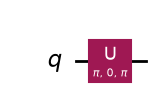

In [14]:
qc.data[0].operation.definition.draw("mpl")

**NOTE :**
- Instructions and circuits are similar
    - instructions do not muatate the original object 
    - circuits muatate the original object 


# Alterantive ways to create circuits

    ## append method
    ## compose method

---

**append method:**

adds one or more instructions to the end of the circuit

_Arguments_:  

    -- an instruction and 

    -- a list of qubits to apply the instruction

---

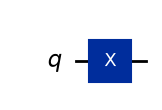

In [15]:
#Example 1
from qiskit.circuit.library import XGate

qc = QuantumCircuit(1)
qc.append(
    XGate(),  # New XGate instruction
    [0],  # Apply to qubit 0
)
qc.draw("mpl")

--- 

convert a circuit to an instruction by using the to_instruction method

---

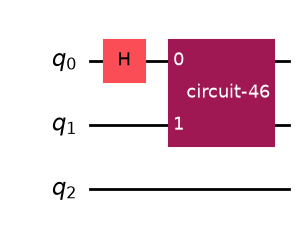

In [16]:
#Example 2


qc_x = QuantumCircuit(2) # quantum circuit with 2 qubits 
qc_x.x(0)               # apply x gate on qubit 0

inst_ex=qc_x.to_instruction() # convert qc_x quantum circuit to an instruction 

qc = QuantumCircuit(3)  # quantum circuit with 3 qubits 
qc.h(0)                # apply h gate on qubit 0 on qc

qc.append(inst_ex,[0,1])      # append inst_ex on new quantum circuit (qc)
qc.draw("mpl")

---

**compose method:**

combine two circuits

Apply the instructions from one circuit onto specified qubits and/or clbits on another.

_Arguments_:  

    -- circuit or instruction to compose onto self

    --  qubits of self 

---

CircuitError: 'Cannot compose onto a circuit with fewer qubits (2 > 1).'

Following with throw error: 

```
qc1 = QuantumCircuit(1)
qc1.x(0)

qc2 = QuantumCircuit(2, name="qc2")

qc2.h(1)

# compose qubits (0, 1) of qc1 to qubits (1, 3) of qc_b respectively
combined = qc1.compose(qc2, qubits=[1, 3])
combined.draw("mpl")

```


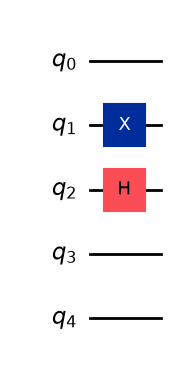

In [17]:
qc1 = QuantumCircuit(3)
qc1.x(1)

qc2 = QuantumCircuit(5, name="qc2")

qc2.h(2)

# compose qubits (0, 1) of qc1 to qubits (1, 3) of qc_b respectively
combined = qc2.compose(qc1)
combined.draw("mpl")

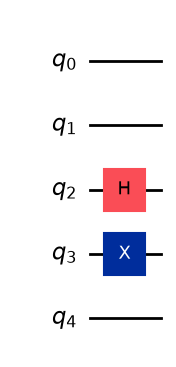

In [18]:
combined = qc2.compose(qc1, qubits=[2,3,4])
combined.draw("mpl")

** NOTE: **
- returns a new circuit 
- To mutate the circuit , use the argument inplace=True.

---

> **decompose method :**

-- Expand each instruction into its definition

-- returns a new QuantumCircuit object 

-- leaves the original circuit completely unchanged

---

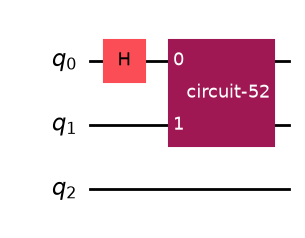

In [19]:
qc1 = QuantumCircuit(2) # quantum circuit with 2 qubits 
qc1.x(0)   
qc1.z(1) 
          

inst_ex=qc1.to_instruction() # convert qc_x quantum circuit to an instruction 

qc = QuantumCircuit(3)  # quantum circuit with 3 qubits 
qc.h(0)   
         # apply h gate on qubit 0 on qc

qc.append(inst_ex,[0,1])      # append inst_ex on new quantum circuit (qc)
qc.draw("mpl")

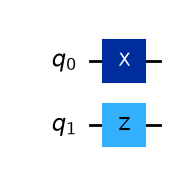

In [20]:
qc1.draw("mpl")

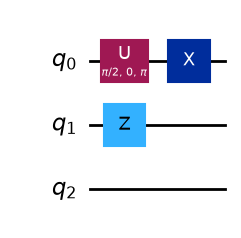

In [21]:
qc.decompose().draw("mpl")

--- 
# Measure qubits

---
<h4>

1. sample the states of individual qubits 
2. transfer the results to a classical register

**Note** 

-- submitting circuits to a Sampler primitive-->  measurements are required

-- circuits submitted to an Estimator primitive -- >must not contain measurements

**Three methods to measure the qubits:**
1. measure
2. measure_all
3. measure_active

</h4>

<h4>

---
**measure**

measures each qubit in the first argument onto the classical bit given as the second argument

---
</h4>


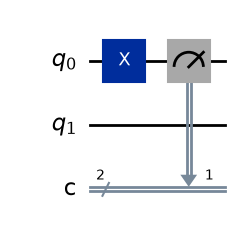

In [22]:
# Example 1
qc = QuantumCircuit(2, 2)
qc.x(0)
qc.measure(0, 1)
qc.draw("mpl")

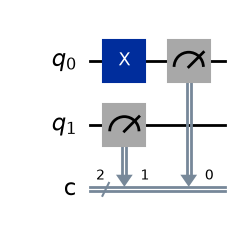

In [23]:
# Example 2
qc = QuantumCircuit(2, 2)
qc.x(0)
qc.measure(0, 0)
qc.measure(1, 1)
qc.draw("mpl")

<h4>

---
**measure_all**

- no argument required 
- circuits without pre-defined cbits
- creates classical bits
- adds a barrier before the measurement

---
</h4>

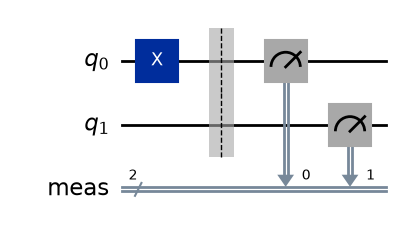

In [24]:
qc = QuantumCircuit(2)
qc.x(0)
qc.measure_all()

qc.draw("mpl")

In [25]:
qc.clbits

[<Clbit register=(2, "meas"), index=0>, <Clbit register=(2, "meas"), index=1>]

---
### **measure_active** : measures only qubits that have operations 

---

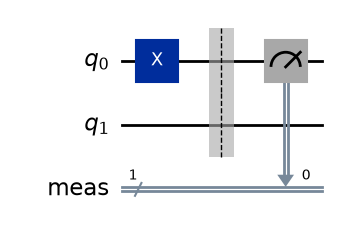

In [26]:
qc = QuantumCircuit(2)
qc.x(0)
qc.measure_active()

qc.draw("mpl")

> ### inverse

### Example 1:

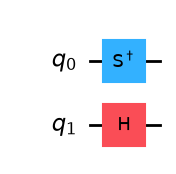

In [27]:
qc = QuantumCircuit(2)
qc.sdg(0)
qc.h(1)

qc.draw("mpl")

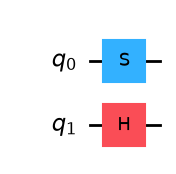

In [28]:
qcInverse= qc.inverse()

qcInverse.draw("mpl")

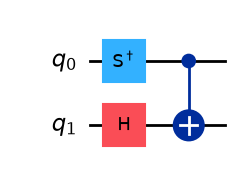

In [29]:
### Example 2:

qc = QuantumCircuit(2)
qc.sdg(0)
qc.h(1)
qc.cx(0,1)

qc.draw("mpl")

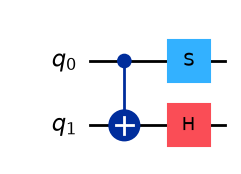

In [30]:
qcInverse= qc.inverse()

qcInverse.draw("mpl")

**NOTE:**
1. order of gates to be noted

2. S gate inverse is SdgGate

3. inverse of gates not availble, remains unchanged

4. non-unitary operations cannot be inverted

 > ### depth() of a quantum circuit is a measure of the number of “layers” of quantum gates, executed in parallel

 https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.QuantumCircuit#depth

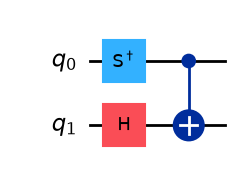

In [31]:

qc = QuantumCircuit(2)
qc.sdg(0)
qc.h(1)
qc.cx(0,1)

qc.draw("mpl")

In [32]:
qc.depth()

2

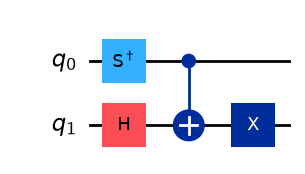

In [33]:
qc = QuantumCircuit(2)
qc.sdg(0)
qc.h(1)
qc.cx(0,1)
qc.x(1)

qc.draw("mpl")

In [34]:
qc.depth()

3